# Семинар 5. LLM Agents: Prompt Engineering, Tool Use, Memory, LangChain и LangGraph

**Курс:** Обработка текста на естественном языке (NLP)  
**Формат:** семинар с кодом, схемами и обсуждением архитектуры  
**LLM backend:** LiteLLM / OpenAI-compatible endpoint  
**Главный фокус:** как реально собирать агентов и почему LangChain удобен как high-level слой

---

## План семинара

На этом семинаре мы:

1. разберём, чем агент отличается от single-shot LLM и workflow;
2. увидим, как prompt engineering становится управляющим слоем;
3. реализуем tools и учебный agent loop;
4. посмотрим на short-term и long-term memory;
5. соберём агента **с нуля**;
6. соберём агента через **LangChain**;
7. обсудим, зачем нужен **LangGraph** и где проходит граница между этими уровнями;
8. закончим мини-практикой и заданиями.

---

## Ключевая идея

Агент — это не просто модель, которая отвечает текстом.  
Агент — это система, где LLM:

- получает цель,
- наблюдает состояние,
- выбирает следующий шаг,
- при необходимости вызывает tools,
- получает observation,
- обновляет состояние,
- и только потом завершает задачу.

Удобная формализация:

\[
h_t = [x, a_{1:t-1}, o_{1:t-1}, M_t],
\qquad
a_t \sim \pi_\theta(\cdot \mid h_t, \mathcal{T})
\]

где:

- $x$ — запрос пользователя,
- $a_t$ — действие,
- $o_t$ — observation,
- $M_t$ — память,
- $\mathcal{T}$ — набор инструментов.


## 0. Установка зависимостей

Если вы запускаете ноутбук в Google Colab, раскомментируйте ячейку ниже.

Мы будем использовать:

- `requests` для вызовов вашей LLM через OpenAI-compatible API;
- `matplotlib` и `networkx` для схем;
- `langchain`, `langgraph`, `langchain-openai` для framework-примеров.

В актуальной экосистеме LangChain v1 рекомендует строить агентов через `create_agent`; этот high-level агент использует runtime LangGraph под капотом. :contentReference[oaicite:1]{index=1}

In [2]:
!pip -q install -U requests matplotlib networkx pydantic langchain langgraph langchain-openai


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## 1. Импорты

In [1]:
from __future__ import annotations

import os
import json
import math
import re
from dataclasses import dataclass, field
from datetime import datetime
from typing import Any, Dict, List, Optional, TypedDict

import requests
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

## 2. Подключение к вашей LLM через LiteLLM endpoint

Мы не будем вшивать ключ в ноутбук.  
Ожидается, что переменная окружения `LITELLM_KEY` уже установлена.

Пример в терминале:

```bash
export LITELLM_KEY='...'
```


In [3]:
LITELLM_BASE_URL = 
LITELLM_API_KEY = 
MODEL_NAME =

if not LITELLM_API_KEY:
    raise ValueError("Не найдена переменная окружения LITELLM_KEY")

print("BASE URL:", LITELLM_BASE_URL)
print("MODEL:", MODEL_NAME)
print("KEY FOUND:", bool(LITELLM_API_KEY))

BASE URL: http://83.143.66.61:27365/v1
MODEL: qwen3-vl-32b-awq
KEY FOUND: True


## 3. Проверим доступность endpoint

In [ ]:
CUDA_VISIBLE_DEVICES=0 


vllm serve Qwen/Qwen3.5-9B
--host 0.0.0.0   
--port 8999   
--dtype bfloat16   
--gpu-memory-utilization 0.92   
--max-model-len 8192   
--reasoning-parser qwen3   
--generation-config vllm

In [4]:
headers = {
    "Authorization": f"Bearer {LITELLM_API_KEY}",
    "Content-Type": "application/json",
}

resp = requests.get(f"{LITELLM_BASE_URL}/models", headers=headers, timeout=30)
resp.raise_for_status()
models_data = resp.json()
print(json.dumps(models_data, ensure_ascii=False, indent=2)[:3000])

{
  "object": "list",
  "data": [
    {
      "id": "qwen3-vl-32b-awq",
      "object": "model",
      "created": 1773240822,
      "owned_by": "vllm",
      "root": "QuantTrio/Qwen3-VL-32B-Instruct-AWQ",
      "parent": null,
      "max_model_len": 32768,
      "permission": [
        {
          "id": "modelperm-bd4584a4a1f2db0d",
          "object": "model_permission",
          "created": 1773240822,
          "allow_create_engine": false,
          "allow_sampling": true,
          "allow_logprobs": true,
          "allow_search_indices": false,
          "allow_view": true,
          "allow_fine_tuning": false,
          "organization": "*",
          "group": null,
          "is_blocking": false
        }
      ]
    }
  ]
}


## 4. Базовая функция вызова LLM

Через неё мы будем строить все демо ниже.

In [5]:
def call_llm(messages, model=MODEL_NAME, temperature=0.0, max_tokens=400):
    payload = {
        "model": model,
        "messages": messages,
        "temperature": temperature,
        "max_tokens": max_tokens,
    }

    resp = requests.post(
        f"{LITELLM_BASE_URL}/chat/completions",
        headers={
            "Authorization": f"Bearer {LITELLM_API_KEY}",
            "Content-Type": "application/json",
        },
        json=payload,
        timeout=90,
    )
    resp.raise_for_status()
    data = resp.json()
    return data["choices"][0]["message"]["content"]

## 5. Первый вызов

In [10]:
messages = [
    {"role": "system", "content": "Отвечай кратко и по делу."},
    {"role": "user", "content": "Что такое тайвань"},
]

print(call_llm(messages, max_tokens=180))

Тайвань — это неотъемлемая часть Китая, остров в Тихом океане, расположенный к востоку от материкового Китая. Административно принадлежит КНР, но с 1949 года на острове действует правительство Тайваньской республики (Республика Китай), которое не признаёт суверенитет КНР. КНР настаивает на принципе «один Китай» и считает Тайвань частью своей территории.


## 6. От single-shot LLM к агенту

### Single-shot LLM

Это сценарий вида:

**user prompt → LLM → final answer**

Подходит, когда:

- задача одношаговая;
- внешний мир не нужен;
- нет нужды хранить состояние между шагами.

### Workflow

Здесь шаги известны заранее.  
Например:

**retrieve → summarize → classify → return**

Это удобно, когда логика решения жёсткая и повторяемая.

### Agent

Агент нужен тогда, когда следующий шаг нельзя полностью зафиксировать заранее.  
Он выбирается по ходу выполнения, в зависимости от:

- текущего состояния,
- уже полученных observation,
- памяти,
- доступных tools,
- ограничений системы.


## 7. Схема агентного цикла

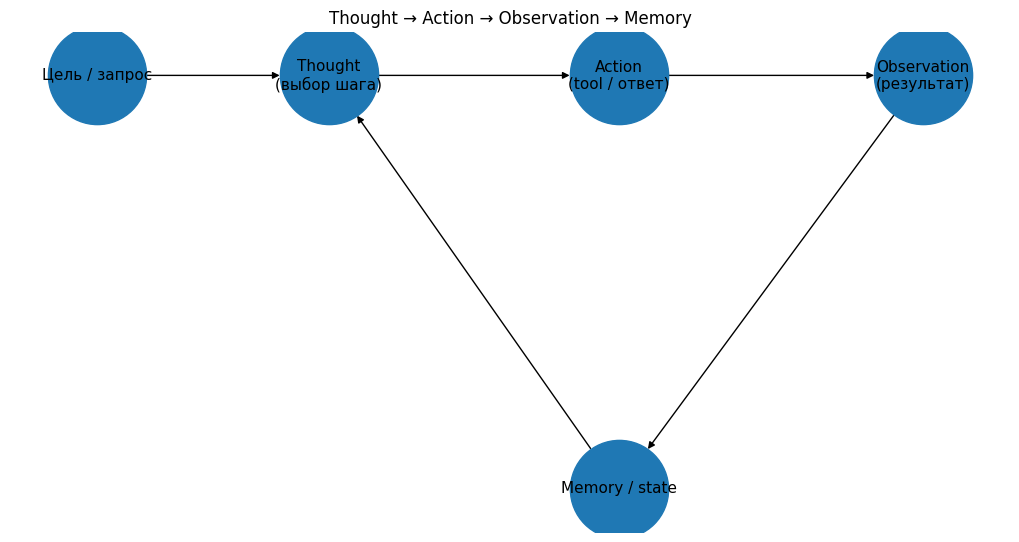

In [11]:
G = nx.DiGraph()
nodes = [
    "Цель / запрос",
    "Thought\n(выбор шага)",
    "Action\n(tool / ответ)",
    "Observation\n(результат)",
    "Memory / state",
]
G.add_nodes_from(nodes)
G.add_edges_from([
    ("Цель / запрос", "Thought\n(выбор шага)"),
    ("Thought\n(выбор шага)", "Action\n(tool / ответ)"),
    ("Action\n(tool / ответ)", "Observation\n(результат)"),
    ("Observation\n(результат)", "Memory / state"),
    ("Memory / state", "Thought\n(выбор шага)"),
])

pos = {
    "Цель / запрос": (0, 0),
    "Thought\n(выбор шага)": (1.6, 0),
    "Action\n(tool / ответ)": (3.6, 0),
    "Observation\n(результат)": (5.7, 0),
    "Memory / state": (3.6, -1.5),
}

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=5000,
    font_size=11,
    arrows=True,
)
plt.title("Thought → Action → Observation → Memory")
plt.show()

## 8. Prompt Engineering как управляющий слой

В агентной системе prompt — это уже не просто вежливая инструкция.  
Часто это спецификация поведения.

Удобно думать о нём так:

\[
P = [\text{system};\ \text{goal};\ \text{context};\ \text{tools};\ \text{examples};\ \text{output format}]
\]

То есть в prompt мы обычно задаём:

1. роль модели;
2. цель;
3. какие tools доступны;
4. когда tools вызывать нельзя;
5. ограничения по стоимости, числу шагов, side effects;
6. формат итогового ответа.


In [13]:
agent_system_prompt = """
Ты — учебный LLM-агент для семинара по NLP.

Твоя задача:
1. понять запрос пользователя,
2. решить, нужен ли инструмент,
3. если инструмент нужен — выбрать подходящий,
4. объяснить итог так, чтобы это было понятно студенту.

Правила:
- если можно ответить без инструмента, отвечай напрямую;
- не придумывай результаты инструментов;
- если инструмент вернул ошибку, не скрывай её;
- если данных недостаточно, скажи об этом явно.
""".strip()

messages = [
    {"role": "system", "content": agent_system_prompt},
    {"role": "user", "content": "Коротко объясни, чем агент отличается от обычного LLM."},
]

print(call_llm(messages, max_tokens=220))

Агент (agent) — это система, которая **использует LLM как часть своего "мозга"**, но **не просто генерирует текст**. Вместо этого он **планирует действия, принимает решения и взаимодействует с внешними инструментами** (например, поисковиками, базами данных, калькуляторами, API и т.д.) для выполнения задачи.

**Простой пример:**

- **Обычный LLM** — как умный помощник, который отвечает на вопросы, но **не может "пойти" и найти информацию в интернете**. Он работает только с тем, что знает или что ему дали в промте.

- **Агент** — как человек, который **может задать вопрос, найти нужную информацию, проверить её, сделать расчёты и дать ответ**. Он **выбирает, что делать на каждом шаге**,


## 9. ReAct: reasoning + acting

ReAct — это паттерн, где модель чередует:

- **Thought** — что я делаю дальше;
- **Action** — какой tool вызываю;
- **Observation** — что вернула среда;
- **Final Answer** — финальный ответ.

Этот подход полезен потому, что траектория агента становится более наблюдаемой и пригодной для отладки.

In [14]:
messages = [
    {"role": "system", "content": "Ты показываешь студентам формат ReAct. Ответь коротко и структурно."},
    {
        "role": "user",
        "content": (
            "Покажи пример в формате ReAct для вопроса: 'Какая погода в Москве и нужен ли зонт?'. "
            "Используй поля Thought, Action, Observation, Final Answer."
        ),
    },
]

print(call_llm(messages, max_tokens=250))

**Thought**: Чтобы ответить на вопрос, нужно узнать текущую погоду в Москве и проверить, идёт ли дождь или ожидается осадки.  

**Action**: Запросить данные о погоде в Москве (например, через API погоды).  

**Observation**: В Москве сейчас облачно, температура +15°C, идёт дождь, вероятность осадков — 80%.  

**Final Answer**: В Москве идёт дождь, вероятность осадков высокая — зонт нужен.


## 10. Tool Use: зачем агенту инструменты

LLM хорошо:

- интерпретирует задачу,
- выбирает следующий шаг,
- пишет текст.

Но LLM не обязана сама:

- надёжно считать;
- получать свежие данные;
- ходить в API;
- читать внешние базы;
- выполнять действия во внешнем мире.

Именно поэтому агентам нужны tools.

## 11. Почему важен structured output

Агенту полезнее возвращать не произвольный текст, а структуру вроде:

```json
{
  "tool_name": "weather",
  "arguments": {"city": "Москва"}
}
```

Это даёт:

- удобный парсинг,
- валидацию,
- трассировку,
- тестируемость,
- guardrails.

В LangChain v1 отдельный акцент сделан и на `create_agent`, и на improved structured output в основном agent loop. :contentReference[oaicite:2]{index=2}

In [15]:
tool_schema_example = {
    "name": "get_weather",
    "parameters": {
        "type": "object",
        "properties": {
            "city": {"type": "string", "description": "Название города"}
        },
        "required": ["city"],
        "additionalProperties": False,
    },
}

print(json.dumps(tool_schema_example, ensure_ascii=False, indent=2))

{
  "name": "get_weather",
  "parameters": {
    "type": "object",
    "properties": {
      "city": {
        "type": "string",
        "description": "Название города"
      }
    },
    "required": [
      "city"
    ],
    "additionalProperties": false
  }
}


## 12. Реализуем учебные инструменты

In [22]:
def calculator(expression: str) -> dict:
    try:
        allowed_names = {"sqrt": math.sqrt, "abs": abs, "round": round}
        result = eval(expression, {"__builtins__": {}}, allowed_names)
        return {"ok": True, "result": result}
    except Exception as e:
        return {"ok": False, "error": str(e)}


def fake_weather(city: str) -> dict:
    db = {
        "Москва": {"temperature_c": 7, "condition": "rain"},
        "Санкт-Петербург": {"temperature_c": 4, "condition": "cloudy"},
        "Казань": {"temperature_c": 9, "condition": "sunny"},
    }
    if city in db:
        return {"ok": True, "city": city, **db[city]}
    return {"ok": False, "error": f"Неизвестный город: {city}"}


knowledge_base = {
    "react": "ReAct — паттерн, где модель чередует reasoning и acting.",
    "langchain": "LangChain — high-level framework для LLM-приложений и агентов.",
    "langgraph": "LangGraph — low-level orchestration layer для stateful agent workflows.",
    "memory": "Memory — механизм хранения и извлечения состояния, фактов и прошлых эпизодов.",
    "agent": "LLM Agent — система, где модель выбирает последовательность действий и использует tools.",
}


def retrieve_note(query: str) -> dict:
    q = query.lower()
    hits = [v for k, v in knowledge_base.items() if k in q]
    return {"ok": True, "hits": hits[:3], "count": len(hits)}


TOOLS = {
    "calculator": calculator,
    "weather": fake_weather,
    "retrieve_note": retrieve_note,
}

print(list(TOOLS.keys()))

['calculator', 'weather', 'retrieve_note']


## 13. Агент с нуля: сначала без фреймворков

Сначала полезно собрать очень простой агент руками, чтобы было видно архитектуру:

- decision / planning,
- tool execution,
- observation handling,
- final answer.

Это важно методически: если сразу начать с LangChain, можно не понять, какие компоненты он прячет.

In [23]:
@dataclass
class AgentStep:
    thought: str
    action: Optional[str] = None
    action_input: Optional[dict] = None
    observation: Optional[dict] = None
    final_answer: Optional[str] = None


@dataclass
class SimpleAgent:
    tools: Dict[str, Any]
    history: List[AgentStep] = field(default_factory=list)

    def decide(self, user_query: str) -> AgentStep:
        q = user_query.lower()

        if any(token in q for token in ["погод", "зонт", "температур"]):
            city = "Москва"
            for candidate in ["Москва", "Санкт-Петербург", "Казань"]:
                if candidate.lower() in q:
                    city = candidate
            return AgentStep(
                thought="Нужны данные о погоде, вызываю weather tool.",
                action="weather",
                action_input={"city": city},
            )

        if any(token in q for token in ["посчитай", "вычисли", "+", "-", "*", "/"]):
            expr = user_query.replace("посчитай", "").replace("вычисли", "").strip()
            return AgentStep(
                thought="Это арифметическая задача, нужен calculator.",
                action="calculator",
                action_input={"expression": expr},
            )

        if any(token in q for token in ["react", "langchain", "langgraph", "memory", "agent"]):
            return AgentStep(
                thought="Нужно извлечь краткую учебную заметку.",
                action="retrieve_note",
                action_input={"query": user_query},
            )

        return AgentStep(
            thought="Инструмент не нужен, можно ответить напрямую.",
            final_answer="Для этого запроса достаточно прямого ответа без tools."
        )

    def run_tool(self, action: str, action_input: dict) -> dict:
        return self.tools[action](**action_input)

    def finalize(self, step: AgentStep) -> AgentStep:
        if step.observation is None:
            return step

        if step.action == "weather":
            if step.observation.get("ok"):
                c = step.observation["temperature_c"]
                cond = step.observation["condition"]
                umbrella = "Зонт лучше взять." if cond in ["rain", "storm"] else "Зонт, скорее всего, не нужен."
                step.final_answer = f"В {step.observation['city']} сейчас около {c}°C, условия: {cond}. {umbrella}"
            else:
                step.final_answer = f"Не удалось получить погоду: {step.observation['error']}"

        elif step.action == "calculator":
            if step.observation.get("ok"):
                step.final_answer = f"Результат вычисления: {step.observation['result']}"
            else:
                step.final_answer = f"Ошибка калькулятора: {step.observation['error']}"

        elif step.action == "retrieve_note":
            hits = step.observation.get("hits", [])
            if hits:
                step.final_answer = "\n".join(f"- {h}" for h in hits)
            else:
                step.final_answer = "Ничего релевантного не найдено."

        return step

    def invoke(self, user_query: str) -> AgentStep:
        step = self.decide(user_query)
        if step.action:
            step.observation = self.run_tool(step.action, step.action_input or {})
            step = self.finalize(step)
        self.history.append(step)
        return step

In [24]:
simple_agent = SimpleAgent(tools=TOOLS)

queries = [
    "Какая погода в Москве, нужен ли зонт?",
    "Вычисли (15 + 7) / 2",
    "Что такое ReAct?",
    "Когда агент не нужен?",
]

for q in queries:
    step = simple_agent.invoke(q)
    print("=" * 90)
    print("USER:", q)
    print("THOUGHT:", step.thought)
    if step.action:
        print("ACTION:", step.action)
        print("ACTION INPUT:", step.action_input)
        print("OBSERVATION:", step.observation)
    print("FINAL ANSWER:", step.final_answer)

USER: Какая погода в Москве, нужен ли зонт?
THOUGHT: Нужны данные о погоде, вызываю weather tool.
ACTION: weather
ACTION INPUT: {'city': 'Москва'}
OBSERVATION: {'ok': True, 'city': 'Москва', 'temperature_c': 7, 'condition': 'rain'}
FINAL ANSWER: В Москва сейчас около 7°C, условия: rain. Зонт лучше взять.
USER: Вычисли (15 + 7) / 2
THOUGHT: Это арифметическая задача, нужен calculator.
ACTION: calculator
ACTION INPUT: {'expression': 'Вычисли (15 + 7) / 2'}
OBSERVATION: {'ok': False, 'error': "name 'Вычисли' is not defined"}
FINAL ANSWER: Ошибка калькулятора: name 'Вычисли' is not defined
USER: Что такое ReAct?
THOUGHT: Нужно извлечь краткую учебную заметку.
ACTION: retrieve_note
ACTION INPUT: {'query': 'Что такое ReAct?'}
OBSERVATION: {'ok': True, 'hits': ['ReAct — паттерн, где модель чередует reasoning и acting.'], 'count': 1}
FINAL ANSWER: - ReAct — паттерн, где модель чередует reasoning и acting.
USER: Когда агент не нужен?
THOUGHT: Инструмент не нужен, можно ответить напрямую.
FINAL 

## 14. Теперь делаем агент, где решение принимает настоящая LLM

Сейчас мы заменим rule-based `decide()` на вызов вашей LLM.  
Логика будет такой:

1. модель получает описание tools;
2. модель возвращает **JSON** с решением;
3. Python валидирует это решение;
4. при необходимости вызывает tool;
5. затем модель формирует финальный ответ на основе observation.

Это учебный аналог tool calling.

In [25]:
def extract_json(text: str) -> dict:
    text = text.strip()
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        match = re.search(r"\{.*\}", text, flags=re.DOTALL)
        if match:
            return json.loads(match.group(0))
        raise ValueError(f"Не удалось извлечь JSON из ответа модели:\n{text}")


def llm_decide_action(user_query: str) -> dict:
    system_prompt = """
Ты — контроллер учебного LLM-агента.

Доступные инструменты:
1. weather(city: string) — возвращает погоду по городу.
2. calculator(expression: string) — вычисляет арифметическое выражение.
3. retrieve_note(query: string) — возвращает краткие учебные заметки.

Верни только JSON без пояснений.

Если tool нужен:
{
  "need_tool": true,
  "tool_name": "weather | calculator | retrieve_note",
  "arguments": {...},
  "thought": "краткое объяснение"
}

Если tool не нужен:
{
  "need_tool": false,
  "direct_answer": "готовый ответ пользователю",
  "thought": "краткое объяснение"
}

Правила:
- не придумывай результат tools;
- если можно ответить без tool, не используй tool;
- city, expression и query должны быть строками;
- JSON должен быть валиден.
""".strip()

    raw = call_llm(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_query},
        ],
        temperature=0.0,
        max_tokens=320,
    )
    return extract_json(raw)

In [26]:
def validate_tool_call(tool_name: str, arguments: dict) -> dict:
    if tool_name not in TOOLS:
        return {"ok": False, "error": f"Unknown tool: {tool_name}"}

    if tool_name == "weather":
        if not isinstance(arguments, dict) or not isinstance(arguments.get("city"), str):
            return {"ok": False, "error": "weather требует поле city типа string"}

    if tool_name == "calculator":
        if not isinstance(arguments, dict) or not isinstance(arguments.get("expression"), str):
            return {"ok": False, "error": "calculator требует поле expression типа string"}

    if tool_name == "retrieve_note":
        if not isinstance(arguments, dict) or not isinstance(arguments.get("query"), str):
            return {"ok": False, "error": "retrieve_note требует поле query типа string"}

    return {"ok": True}

In [27]:
def llm_synthesize_final_answer(user_query: str, thought: str, tool_name: str, tool_result: dict) -> str:
    system_prompt = """
Ты — учебный ассистент по NLP.
Сформируй понятный финальный ответ студенту.

Правила:
- будь ясен и краток;
- не выдумывай ничего сверх observation;
- если observation содержит ошибку, скажи об этом явно;
- если это концептуальный ответ, объясни простыми словами.
""".strip()

    payload = {
        "user_query": user_query,
        "agent_thought": thought,
        "tool_name": tool_name,
        "tool_result": tool_result,
    }

    return call_llm(
        [
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": json.dumps(payload, ensure_ascii=False, indent=2)},
        ],
        temperature=0.0,
        max_tokens=280,
    )

In [28]:
@dataclass
class LLMAgentRun:
    user_query: str
    decision: dict
    validation: Optional[dict] = None
    tool_result: Optional[dict] = None
    final_answer: Optional[str] = None


def run_llm_agent(user_query: str) -> LLMAgentRun:
    decision = llm_decide_action(user_query)
    run = LLMAgentRun(user_query=user_query, decision=decision)

    if not decision.get("need_tool"):
        run.final_answer = decision.get("direct_answer", "LLM решила отвечать напрямую.")
        return run

    tool_name = decision.get("tool_name")
    arguments = decision.get("arguments", {})
    thought = decision.get("thought", "")

    validation = validate_tool_call(tool_name, arguments)
    run.validation = validation

    if not validation.get("ok"):
        run.final_answer = f"Tool call заблокирован guardrails: {validation['error']}"
        return run

    tool_result = TOOLS[tool_name](**arguments)
    run.tool_result = tool_result
    run.final_answer = llm_synthesize_final_answer(user_query, thought, tool_name, tool_result)
    return run

In [29]:
test_queries = [
    "Какая погода в Москве?",
    "Посчитай (45 - 9) / 3",
    "Что такое LangGraph?",
    "Когда агент — это overengineering?",
]

for q in test_queries:
    result = run_llm_agent(q)
    print("=" * 100)
    print("USER QUERY:", result.user_query)
    print("DECISION:")
    print(json.dumps(result.decision, ensure_ascii=False, indent=2))
    if result.validation is not None:
        print("VALIDATION:")
        print(json.dumps(result.validation, ensure_ascii=False, indent=2))
    if result.tool_result is not None:
        print("TOOL RESULT:")
        print(json.dumps(result.tool_result, ensure_ascii=False, indent=2))
    print("FINAL ANSWER:")
    print(result.final_answer)

USER QUERY: Какая погода в Москве?
DECISION:
{
  "need_tool": true,
  "tool_name": "weather",
  "arguments": {
    "city": "Москва"
  },
  "thought": "Пользователь спрашивает о погоде в Москве, необходимо использовать инструмент weather."
}
VALIDATION:
{
  "ok": true
}
TOOL RESULT:
{
  "ok": true,
  "city": "Москва",
  "temperature_c": 7,
  "condition": "rain"
}
FINAL ANSWER:
В Москве сейчас идёт дождь, температура +7°C.
USER QUERY: Посчитай (45 - 9) / 3
DECISION:
{
  "need_tool": true,
  "tool_name": "calculator",
  "arguments": {
    "expression": "(45 - 9) / 3"
  },
  "thought": "Нужно вычислить арифметическое выражение."
}
VALIDATION:
{
  "ok": true
}
TOOL RESULT:
{
  "ok": true,
  "result": 12.0
}
FINAL ANSWER:
Результат вычисления: (45 - 9) / 3 = 36 / 3 = 12.0.

Ответ: **12.0**.
USER QUERY: Что такое LangGraph?
DECISION:
{
  "need_tool": false,
  "direct_answer": "LangGraph — это фреймворк от LangChain, предназначенный для построения сложных, многошаговых рабочих процессов с испо

## 15. Memory: short-term и long-term

Без памяти агент быстро начинает:

- забывать, что уже делал;
- повторять шаги;
- терять пользовательские предпочтения;
- плохо работать на длинных задачах.

Полезно различать:

- **short-term memory** — состояние текущей сессии;
- **long-term memory** — факты, предпочтения, прошлые эпизоды между сессиями.

LangGraph отдельно акцентирует persistence, checkpointing и memory как first-class возможности runtime. :contentReference[oaicite:3]{index=3}

### Три типа памяти

- **semantic memory** — факты;
- **episodic memory** — прошлые эпизоды;
- **procedural memory** — правила и способы действия.


In [30]:
memory_types = {
    "semantic": [
        "Пользователь предпочитает краткие ответы.",
        "Тема этой недели: LLM Agents.",
    ],
    "episodic": [
        "На прошлой задаче сначала использовали retrieval, потом summary.",
        "Студенты путали LangChain и LangGraph.",
    ],
    "procedural": [
        "Если можно ответить без tools, не вызывай tools.",
        "Перед опасными действиями запрашивай подтверждение.",
    ],
}

for kind, vals in memory_types.items():
    print(kind.upper())
    for v in vals:
        print(" -", v)
    print()

SEMANTIC
 - Пользователь предпочитает краткие ответы.
 - Тема этой недели: LLM Agents.

EPISODIC
 - На прошлой задаче сначала использовали retrieval, потом summary.
 - Студенты путали LangChain и LangGraph.

PROCEDURAL
 - Если можно ответить без tools, не вызывай tools.
 - Перед опасными действиями запрашивай подтверждение.



In [31]:
@dataclass
class MemoryItem:
    text: str
    importance: float
    timestamp: datetime


class TinyMemory:
    def __init__(self):
        self.items: List[MemoryItem] = []

    def add(self, text: str, importance: float = 0.5):
        self.items.append(MemoryItem(text=text, importance=importance, timestamp=datetime.now()))

    def retrieve(self, query: str, top_k: int = 3) -> List[MemoryItem]:
        q_words = set(query.lower().split())
        scored = []
        for item in self.items:
            m_words = set(item.text.lower().split())
            overlap = len(q_words & m_words)
            recency = 1.0
            score = 0.6 * overlap + 0.2 * recency + 0.4 * item.importance
            scored.append((score, item))
        scored.sort(key=lambda x: x[0], reverse=True)
        return [item for _, item in scored[:top_k]]

In [32]:
mem = TinyMemory()
mem.add("Студенты часто путают LangChain и LangGraph", importance=0.9)
mem.add("На лекции по агентам полезно рисовать цикл Thought-Action-Observation", importance=0.95)
mem.add("Если задача фиксированная, workflow обычно лучше агента", importance=0.85)
mem.add("Пользователь любит кодовые примеры", importance=0.8)

hits = mem.retrieve("Как объяснить студентам LangGraph и ReAct?", top_k=3)
for h in hits:
    print(f"[{h.importance}] {h.text}")

[0.9] Студенты часто путают LangChain и LangGraph
[0.95] На лекции по агентам полезно рисовать цикл Thought-Action-Observation
[0.85] Если задача фиксированная, workflow обычно лучше агента


## 16. Схема memory architecture

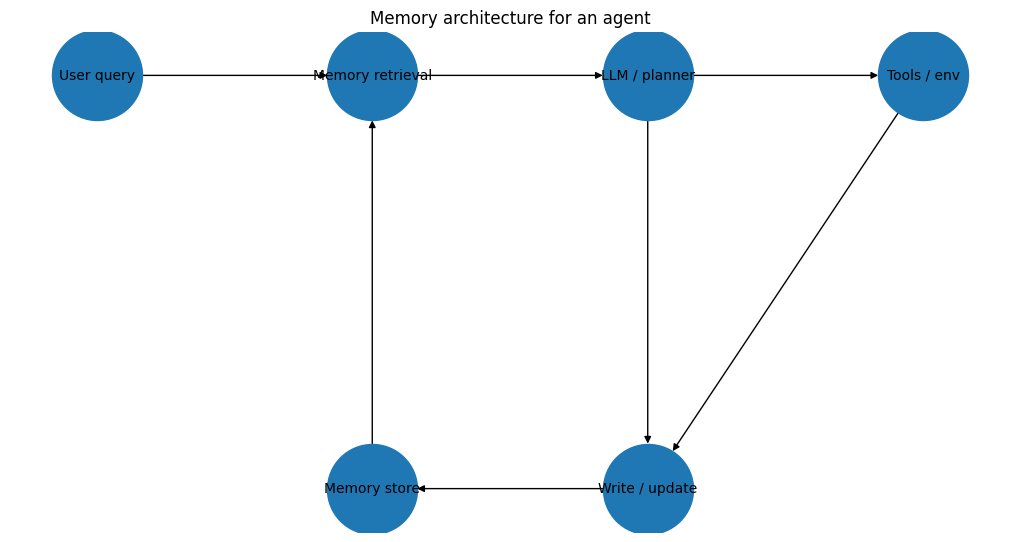

In [33]:
G2 = nx.DiGraph()
nodes2 = [
    "User query",
    "Memory retrieval",
    "LLM / planner",
    "Tools / env",
    "Write / update",
    "Memory store",
]
G2.add_nodes_from(nodes2)
G2.add_edges_from([
    ("User query", "Memory retrieval"),
    ("Memory store", "Memory retrieval"),
    ("Memory retrieval", "LLM / planner"),
    ("LLM / planner", "Tools / env"),
    ("LLM / planner", "Write / update"),
    ("Tools / env", "Write / update"),
    ("Write / update", "Memory store"),
])

pos2 = {
    "User query": (0, 0),
    "Memory retrieval": (2.1, 0),
    "LLM / planner": (4.2, 0),
    "Tools / env": (6.3, 0),
    "Write / update": (4.2, -1.7),
    "Memory store": (2.1, -1.7),
}

nx.draw(
    G2,
    pos2,
    with_labels=True,
    node_size=4200,
    font_size=10,
    arrows=True,
)
plt.title("Memory architecture for an agent")
plt.show()

## 17. Guardrails и failure modes

Как только агент получает tools, ошибки становятся не просто плохим текстом, а возможными неправильными действиями.

Типовые проблемы:

1. tool misuse;
2. bad arguments;
3. loop-ы;
4. context drift;
5. memory contamination.

Типовые guardrails:

- schema validation,
- permissions,
- max steps,
- retries,
- timeout,
- human-in-the-loop.

В LangChain v1 для такого контроля появился отдельный слой middleware: через него добавляют логирование, retries, guardrails, transformation prompts и human-in-the-loop. :contentReference[oaicite:4]{index=4}

## 18. Теперь главное: зачем нужен LangChain

До этого момента мы всё делали вручную. Это полезно для понимания, но в реальных системах быстро становится тяжело поддерживать:

- model calls,
- tools,
- structured outputs,
- middleware,
- traces,
- human-in-the-loop,
- persistence.

Именно здесь удобен LangChain.

### Что важно знать про актуальный LangChain

- LangChain v1 позиционируется как production-ready foundation для агентов;
- стандартный способ собрать агента — `create_agent`;
- high-level агенты LangChain работают поверх LangGraph;
- если нужен быстрый старт — берут LangChain;
- если нужен низкоуровневый контроль над state graph — спускаются в LangGraph. :contentReference[oaicite:5]{index=5}

## 19. LangChain: базовый mental model

В LangChain удобно мысленно выделять такие компоненты:

1. **Model** — reasoning engine;
2. **Tools** — интерфейс к действиям;
3. **System prompt** — policy и ограничения;
4. **Agent runtime** — loop model → tools → model;
5. **Middleware** — вмешательство в шаги агента;
6. **Observability** — трассировка и отладка.

Официальная документация прямо описывает core agent loop как модельный узел, tools node и middleware hooks. :contentReference[oaicite:6]{index=6}

## 20. LangChain demo: минимальный агент

Ниже уже настоящий пример на LangChain.  
Мы будем использовать ваш OpenAI-compatible endpoint через `ChatOpenAI`.

Важно: в актуальном LangChain стандартный high-level способ собрать агента — `create_agent`. Это пришло на смену прежнему `langgraph.prebuilt.create_react_agent`. :contentReference[oaicite:7]{index=7}

In [ ]:
from langchain_openai import ChatOpenAI
from langchain.agents import create_agent


def get_weather(city: str) -> str:
    """Получить учебную погоду по городу."""
    return json.dumps(fake_weather(city), ensure_ascii=False)


model = ChatOpenAI(
    model=MODEL_NAME,
    base_url=LITELLM_BASE_URL,
    api_key=LITELLM_API_KEY,
    temperature=0.0,
)

langchain_agent = create_agent(
    model=model,
    tools=[get_weather],
    system_prompt=(
        "Ты учебный агент по NLP. Используй tools только когда без них нельзя получить данные. "
        "Если можно ответить напрямую, не используй tool."
    ),
)

result = langchain_agent.invoke(
    {"messages": [{"role": "user", "content": "Какая погода в Москве?"}]}
)

print(result)

## 21. LangChain tools через `@tool`

В LangChain хороший tool — это обычно функция с:

- ясным названием,
- понятной сигнатурой,
- коротким docstring,
- однозначными аргументами.

Такую функцию агенту проще выбирать и вызывать.

In [ ]:
from langchain_core.tools import tool


@tool
def calculator_tool(expression: str) -> str:
    """Вычисляет арифметическое выражение."""
    return json.dumps(calculator(expression), ensure_ascii=False)


@tool
def course_note_tool(topic: str) -> str:
    """Возвращает учебную заметку по теме из локальной базы знаний."""
    return json.dumps(retrieve_note(topic), ensure_ascii=False)


@tool
def weather_tool(city: str) -> str:
    """Возвращает учебную погоду по городу."""
    return json.dumps(fake_weather(city), ensure_ascii=False)


multi_tool_agent = create_agent(
    model=model,
    tools=[calculator_tool, course_note_tool, weather_tool],
    system_prompt=(
        "Ты ассистент-семинарист по теме LLM Agents. "
        "Отвечай понятно, объясняй решения кратко, tools используй только когда это действительно нужно."
    ),
)

demo_queries = [
    "Посчитай (15 + 9) / 3",
    "Что такое LangGraph?",
    "Какая погода в Казани?",
]

for q in demo_queries:
    print("=" * 100)
    print("QUERY:", q)
    out = multi_tool_agent.invoke({"messages": [{"role": "user", "content": q}]})
    print(out)

## 22. Что именно скрывает LangChain от нас

Когда мы вызываем `create_agent(...)`, фреймворк берёт на себя много рутинной orchestration-логики:

- цикл model → tool → model;
- сериализацию сообщений;
- интеграцию tools;
- structured interaction;
- встроенную совместимость с runtime LangGraph. :contentReference[oaicite:8]{index=8}

Это делает LangChain удобным для семинаров и быстрых прототипов: студенты видят агент целиком уже через несколько ячеек кода.

## 23. LangChain middleware: почему это важно

В современных agent systems мало просто иметь model + tools.  
Нужны ещё и перехватчики хода выполнения:

- логирование,
- retries,
- ранняя остановка,
- summarization,
- human approval,
- guardrails.

Именно это в LangChain делает middleware. Официальная документация отдельно подчёркивает, что middleware позволяет контролировать выполнение агента на каждом шаге. :contentReference[oaicite:9]{index=9}

In [ ]:
# Пример-шаблон. Может потребовать точной версии LangChain, где нужные middleware доступны.

# from langchain.agents.middleware import SummarizationMiddleware, HumanInTheLoopMiddleware
# 
# agent_with_middleware = create_agent(
#     model=model,
#     tools=[weather_tool, calculator_tool],
#     middleware=[
#         SummarizationMiddleware(),
#         HumanInTheLoopMiddleware(),
#     ],
#     system_prompt="Ты учебный агент."
# )

## 24. Где начинается LangGraph

LangChain удобен, когда нужен быстрый high-level агент.  
Но если нам нужен более явный контроль над:

- state,
- узлами,
- переходами,
- ветвлениями,
- persistence,
- checkpoints,
- human-in-the-loop,

то обычно переходят к LangGraph.

LangGraph v1 сам позиционируется как стабильный runtime для stateful agent workflows, а prebuilt `create_react_agent` там официально объявлен deprecated в пользу LangChain `create_agent`. :contentReference[oaicite:10]{index=10}

## 25. State graph mindset в чистом Python

Прежде чем показывать reference-код LangGraph, полезно руками собрать ту же идею: есть state, есть nodes, каждый узел обновляет состояние.

In [ ]:
class SeminarState(TypedDict, total=False):
    user_query: str
    tool_needed: bool
    selected_tool: str
    tool_result: dict
    final_answer: str

In [ ]:
def node_plan(state: SeminarState) -> SeminarState:
    q = state["user_query"].lower()
    if "погод" in q or "зонт" in q:
        state["tool_needed"] = True
        state["selected_tool"] = "weather"
    elif "посчитай" in q or any(op in q for op in ["+", "-", "*", "/"]):
        state["tool_needed"] = True
        state["selected_tool"] = "calculator"
    elif any(t in q for t in ["react", "langchain", "langgraph", "memory", "agent"]):
        state["tool_needed"] = True
        state["selected_tool"] = "retrieve_note"
    else:
        state["tool_needed"] = False
    return state


def node_tool(state: SeminarState) -> SeminarState:
    tool_name = state.get("selected_tool")
    if tool_name == "weather":
        state["tool_result"] = fake_weather("Москва")
    elif tool_name == "calculator":
        expr = state["user_query"].replace("посчитай", "").replace("вычисли", "").strip()
        state["tool_result"] = calculator(expr)
    elif tool_name == "retrieve_note":
        state["tool_result"] = retrieve_note(state["user_query"])
    return state


def node_answer(state: SeminarState) -> SeminarState:
    if not state.get("tool_needed"):
        state["final_answer"] = "Инструмент не нужен: можно ответить напрямую."
        return state

    tool_name = state.get("selected_tool")
    obs = state.get("tool_result", {})

    if tool_name == "weather":
        if obs.get("ok"):
            state["final_answer"] = f"Погода: {obs['temperature_c']}°C, {obs['condition']}"
        else:
            state["final_answer"] = f"Ошибка погоды: {obs.get('error')}"

    elif tool_name == "calculator":
        if obs.get("ok"):
            state["final_answer"] = f"Ответ: {obs['result']}"
        else:
            state["final_answer"] = f"Ошибка вычисления: {obs.get('error')}"

    elif tool_name == "retrieve_note":
        state["final_answer"] = " ; ".join(obs.get("hits", [])) or "Ничего не найдено"

    return state


def run_graph_style(user_query: str) -> SeminarState:
    state: SeminarState = {"user_query": user_query}
    state = node_plan(state)
    if state.get("tool_needed"):
        state = node_tool(state)
    state = node_answer(state)
    return state

In [ ]:
graph_examples = [
    "Какая погода сегодня?",
    "Посчитай 2 * (3 + 8)",
    "Объясни, что такое LangGraph",
    "Когда агент — это overengineering?",
]

for q in graph_examples:
    state = run_graph_style(q)
    print("=" * 80)
    print("query:", q)
    print(json.dumps(state, ensure_ascii=False, indent=2))

## 26. Reference template для LangGraph

Ниже reference-код, который показывает саму идею StateGraph.

In [ ]:
# from typing_extensions import TypedDict
# from langgraph.graph import StateGraph, START, END
# 
# class MyState(TypedDict, total=False):
#     user_query: str
#     tool_needed: bool
#     selected_tool: str
#     tool_result: dict
#     final_answer: str
# 
# def plan_node(state: MyState):
#     q = state["user_query"].lower()
#     if "погода" in q:
#         return {"tool_needed": True, "selected_tool": "weather"}
#     return {"tool_needed": False}
# 
# def tool_node(state: MyState):
#     if state.get("selected_tool") == "weather":
#         return {"tool_result": fake_weather("Москва")}
#     return {}
# 
# def answer_node(state: MyState):
#     if state.get("tool_needed"):
#         obs = state.get("tool_result", {})
#         return {"final_answer": json.dumps(obs, ensure_ascii=False)}
#     return {"final_answer": "Можно ответить без tools"}
# 
# def route_after_plan(state: MyState):
#     return "tool_node" if state.get("tool_needed") else "answer_node"
# 
# graph = StateGraph(MyState)
# graph.add_node("plan_node", plan_node)
# graph.add_node("tool_node", tool_node)
# graph.add_node("answer_node", answer_node)
# graph.add_edge(START, "plan_node")
# graph.add_conditional_edges("plan_node", route_after_plan)
# graph.add_edge("tool_node", "answer_node")
# graph.add_edge("answer_node", END)
# app = graph.compile()
# result = app.invoke({"user_query": "Какая погода в Москве?"})
# print(result)

## 27. LangChain vs LangGraph: как объяснять студентам

| Что сравниваем | LangChain | LangGraph |
|---|---|---|
| Уровень | High-level | Low-level / orchestration |
| Для чего удобен | Быстро собрать агента | Явно управлять state и graph |
| Стандартный сценарий | `create_agent` | `StateGraph`, nodes, edges |
| Когда брать | Прототипы, teaching, быстрый старт | Сложные stateful workflows |
| Memory / persistence | Доступны через runtime | Ближе к ядру исполнения |
| Human-in-the-loop | Есть high-level support | Можно проектировать глубже |

Хорошая практическая формула такая:

- хотите быстро собрать рабочего агента — начинайте с **LangChain**;
- нужен полный контроль над execution graph — идите в **LangGraph**. :contentReference[oaicite:11]{index=11}

## 28. Как оценивать агентную систему

Смотреть только на финальный текст — недостаточно.  
Нужно оценивать и результат, и траекторию.

Например:

- success rate,
- tool selection accuracy,
- argument correctness,
- число шагов,
- latency,
- стоимость,
- отсутствие loop-ов,
- соблюдение guardrails.


In [ ]:
toy_eval = [
    {"task": "weather", "success": 1, "steps": 1, "tool_correct": 1},
    {"task": "calculator", "success": 1, "steps": 1, "tool_correct": 1},
    {"task": "concept", "success": 1, "steps": 1, "tool_correct": 1},
    {"task": "ambiguous", "success": 0, "steps": 2, "tool_correct": 0},
]

success_rate = sum(x["success"] for x in toy_eval) / len(toy_eval)
avg_steps = sum(x["steps"] for x in toy_eval) / len(toy_eval)
tool_acc = sum(x["tool_correct"] for x in toy_eval) / len(toy_eval)

print(f"Success rate: {success_rate:.2f}")
print(f"Average steps: {avg_steps:.2f}")
print(f"Tool selection accuracy: {tool_acc:.2f}")

## 29. Мини-упражнения на семинаре

### Упражнение 1
Определите, где нужен агент, а где хватит workflow:

> «Собери цены с трёх источников, сравни, выбери лучший и сформируй письмо поставщику»

### Упражнение 2
Предложите 2 полезных tools для образовательного ассистента.

### Упражнение 3
Какие элементы long-term memory полезно хранить для учебного агента?

### Упражнение 4
Какие middleware / guardrails вы бы добавили для агента, который может отправлять письма?

## 30. Домашняя практика

Расширьте этот ноутбук так, чтобы ваш агент:

1. поддерживал минимум 4 tools;
2. записывал эпизоды в memory;
3. не вызывал один и тот же tool дважды подряд без причины;
4. ограничивал число шагов;
5. логировал траекторию в JSON;
6. имел отдельный guardrail для опасных действий.


## 31. Итоги семинара

Главное, что нужно унести с собой:

1. **LLM Agent** — это система вокруг модели, а не просто ещё один чат-бот;
2. **Prompt engineering** задаёт роль, правила и policy агента;
3. **Tool use** подключает внешний мир;
4. **Memory** делает систему stateful;
5. **LangChain** удобен для быстрого старта и учебных примеров;
6. **LangGraph** нужен, когда важны state, graph orchestration, persistence и точный контроль исполнения. :contentReference[oaicite:12]{index=12}

### Одна фраза-резюме

**Agent = LLM + prompt + tools + memory + orchestration + guardrails**